# Homework 3 | Survival Analysis 
Student: Anna Mikayelyan


## Necessary libraries 

In [1]:
import pandas as pd 
import os
from sklearn.preprocessing import LabelEncoder
from lifelines import ( 
    BreslowFlemingHarringtonFitter, 
    ExponentialFitter, 
    GeneralizedGammaFitter, 
    KaplanMeierFitter, 
    LogLogisticFitter, 
    LogNormalFitter, 
    MixtureCureFitter, 
    NelsonAalenFitter, 
    PiecewiseExponentialFitter, 
    SplineFitter, 
    WeibullFitter
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data Exploration & Preprocessing

The dataset includes customer demographic and usage data, with the target variable being churn, indicating whether a customer has churned. The preprocessing steps involve converting the churn column to binary values, where **1** indicates **churned (Yes)** and **0** indicates **not churned (No)**. Categorical variables such as **region, marital, ed, retire, gender, voice, internet, forward,** and **custcate** are transformed into numeric codes. Then, encoded categorical columns using LabelEncoder for binary features and one-hot encoding for multi-category features

In [2]:
data_path = os.path.join(os.getcwd(), 'data', 'telco.csv')

In [3]:
df = pd.read_csv(data_path)

In [4]:
df.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [5]:
df.describe()

,ID,tenure,age,address,income
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,35.526000,41.684000,11.551000,77.535000
std,288.819436,21.359812,12.558816,10.086681,107.044165
min,1.000000,1.000000,18.000000,0.000000,9.000000
25%,250.750000,17.000000,32.000000,3.000000,29.000000
50%,500.500000,34.000000,40.000000,9.000000,47.000000
75%,750.250000,54.000000,51.000000,18.000000,83.000000
max,1000.000000,72.000000,77.000000,55.000000,1668.000000


In [6]:
print(df.columns)

Index(['ID', 'region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'retire', 'gender', 'voice', 'internet', 'forward', 'custcat', 'churn'],
      dtype='object')


In [7]:
# Checking for missing values
df.isnull().sum()

ID          0
region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
retire      0
gender      0
voice       0
internet    0
forward     0
custcat     0
churn       0
dtype: int64

In [8]:
# Checking data types
print(df.dtypes)

ID           int64
region      object
tenure       int64
age          int64
marital     object
address      int64
income       int64
ed          object
retire      object
gender      object
voice       object
internet    object
forward     object
custcat     object
churn       object
dtype: object


In [9]:
# Converting churn column to numeric (0: not churned, 1: churned)
df["churn"] = df["churn"].apply(lambda x: 1 if x == "Yes" else 0)

In [10]:
df.columns = df.columns.str.strip()

In [11]:
le = LabelEncoder()

In [12]:
# Applying label encoding to columns which are binary
df['retire'] = le.fit_transform(df['retire'])
df['voice'] = le.fit_transform(df['voice'])
df['internet'] = le.fit_transform(df['internet'])
df['forward'] = le.fit_transform(df['forward'])
df['gender'] = le.fit_transform(df['gender'])

In [13]:
# One-hot encoding for the multi-category columns
df = pd.get_dummies(df, columns=['region', 'marital', 'ed', 'custcat'], drop_first=True)

In [14]:
# Checking again to confirm 
print(df.dtypes)

ID                                 int64
tenure                             int64
age                                int64
address                            int64
income                             int64
retire                             int32
gender                             int32
voice                              int32
internet                           int32
forward                            int32
churn                              int64
region_Zone 2                       bool
region_Zone 3                       bool
marital_Unmarried                   bool
ed_Did not complete high school     bool
ed_High school degree               bool
ed_Post-undergraduate degree        bool
ed_Some college                     bool
custcat_E-service                   bool
custcat_Plus service                bool
custcat_Total service               bool
dtype: object


In [15]:
# Defining
T = df["tenure"]
E = df["churn"]

## Building AFT models with all the available distributions

In this section, I go through all the survival model fitters listed in the provided resource, including both parametric AFT distributions and non-parametric estimators. Each model is fitted using the **tenure** variable as the survival time and the **churn** variable as the event indicator. The goal is to evaluate which models are applicable, which models fit the data successfully, and how their performance compares based on **log-likelihood**, **AIC**, and the **shape of the survival curve**.

In [16]:
# AalenJohansenFitter

The ***AalenJohansenFitter*** is conceptually invalid for this dataset because the churn variable has only one event category, meaning no competing risks exist. Including this model would misrepresent the structure of the data and produce incorrect results.

In [17]:
# BreslowFlemingHarringtonFitter 

bfhf = BreslowFlemingHarringtonFitter()
bfhf.fit(T, E, label="Breslow-Fleming-Harrington")

<lifelines.BreslowFlemingHarringtonFitter:"Breslow-Fleming-Harrington", fitted with 1000 total observations, 726 right-censored observations>

In [18]:
# Exponential 

exp = ExponentialFitter()
exp.fit(T, E, label="Exponential")
exp.print_summary()

<lifelines.ExponentialFitter:"Exponential", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.98
               hypothesis = lambda_ != 0

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 129.66      7.83          114.30          145.01

         cmp to     z      p  -log2(p)
lambda_    0.00 16.55 <0.005    202.03
---
AIC = 3215.96

In [19]:
# GeneralizedGammaFitter 

gg = GeneralizedGammaFitter()
gg.fit(T, E, label="GeneralizedGamma")
gg.print_summary()

<lifelines.GeneralizedGammaFitter:"GeneralizedGamma", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.50
               hypothesis = mu_ != 0, ln_sigma_ != 0, lambda_ != 1

---
           coef  se(coef)  coef lower 95%  coef upper 95%
mu_        4.79      0.14            4.51            5.06
ln_sigma_  0.57      0.14            0.29            0.85
lambda_    0.05      0.33           -0.60            0.70

           cmp to     z      p  -log2(p)
mu_          0.00 34.09 <0.005    843.87
ln_sigma_    0.00  4.02 <0.005     14.08
lambda_      1.00 -2.87 <0.005      7.92
---
AIC = 3211.01

In [20]:
# KaplanMeierFitter 

kmf = KaplanMeierFitter()
kmf.fit(T, E, label="Kaplan-Meier")

<lifelines.KaplanMeierFitter:"Kaplan-Meier", fitted with 1000 total observations, 726 right-censored observations>

In [21]:
# LogLogisticFitter 

loglog = LogLogisticFitter()
loglog.fit(T, E, label="LogLogistic")
loglog.print_summary()

<lifelines.LogLogisticFitter:"LogLogistic", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.21
               hypothesis = alpha_ != 1, beta_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
alpha_ 103.39      9.13           85.50          121.28
beta_    1.04      0.05            0.93            1.15

        cmp to     z      p  -log2(p)
alpha_    1.00 11.22 <0.005     94.60
beta_     1.00  0.73   0.46      1.11
---
AIC = 3214.42

In [22]:
# LogNormalFitter 

lognorm = LogNormalFitter()
lognorm.fit(T, E, label="LogNormal")
lognorm.print_summary()

<lifelines.LogNormalFitter:"LogNormal", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.52
               hypothesis = mu_ != 0, sigma_ != 1

---
        coef  se(coef)  coef lower 95%  coef upper 95%
mu_     4.77      0.10            4.57            4.98
sigma_  1.81      0.09            1.64            1.97

        cmp to     z      p  -log2(p)
mu_       0.00 46.06 <0.005       inf
sigma_    1.00  9.37 <0.005     66.94
---
AIC = 3209.04

In [23]:
# MixtureCureFitter 

base_model = WeibullFitter()
mcf = MixtureCureFitter(base_fitter=base_model)
mcf.fit(T, E, label="MixtureCure")
mcf.print_summary()

<lifelines.MixtureCureFitter:"MixtureCure", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.68
               hypothesis = cured_fraction_ != 0, lambda_ != 1, rho_ != 1

---
                 coef  se(coef)  coef lower 95%  coef upper 95%
cured_fraction_  0.38      0.16            0.07            0.69
lambda_         68.72     26.31           17.16          120.28
rho_             1.02      0.08            0.87            1.18

                 cmp to    z    p  -log2(p)
cured_fraction_    0.00 2.42 0.02      6.01
lambda_            1.00 2.57 0.01      6.64
rho_               1.00 0.31 0.76      0.40
---
AIC = 3217.36

In [24]:
# NelsonAalenFitter 

naf = NelsonAalenFitter()
naf.fit(T, E, label="Nelson-Aalen")

# Converting cumulative hazard H(t) to survival: S(t) = exp(-H(t))
naf.survival_function_ = np.exp(-naf.cumulative_hazard_)

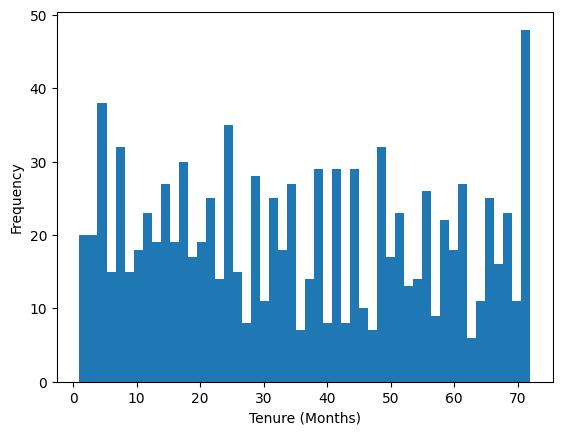

In [25]:
# Plotting to understand how to define breakpoints for PiecewiseExponentialFitter
plt.hist(df['tenure'], bins=50)  
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()

In [26]:
# PiecewiseExponentialFitter 

breakpoints = [12, 24, 36, 48, 60]

pwexp = PiecewiseExponentialFitter(breakpoints=breakpoints)
pwexp.fit(T, E, label="PiecewiseExponential")

<lifelines.PiecewiseExponentialFitter:"PiecewiseExponential", fitted with 1000 total observations, 726 right-censored observations>

In [27]:
#  SplineFitter

max_time = T.max()
knot_locations = np.arange(0, max_time, 12)[1:]

spline = SplineFitter(knot_locations=knot_locations)
spline.fit(T, E, label="Spline")
spline.print_summary()

<lifelines.SplineFitter:"Spline", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1603.76
               hypothesis = phi_0_ != 0, phi_1_ != 0, phi_2_ != 0, phi_3_ != 0, phi_4_ != 0

---
        coef  se(coef)  coef lower 95%  coef upper 95%
phi_0_ -4.96      0.26           -5.47           -4.44
phi_1_  1.08      0.09            0.91            1.25
phi_2_  0.74      0.57           -0.38            1.86
phi_3_ -0.59      1.68           -3.90            2.71
phi_4_ -0.35      2.22           -4.71            4.00

        cmp to      z      p  -log2(p)
phi_0_    0.00 -18.89 <0.005    261.94
phi_1_    0.00  12.40 <0.005    114.92
phi_2_    0.00   1.30   0.19      2.37
phi_3_    0.00  -0.35   0.72      0.47
phi_4_    0.00  -0.16   0.87      0.20
---
AIC = 3217.52

In [28]:
# WeibullAFTFitter 

weibull = WeibullFitter()
weibull.fit(T, E, label="Weibull")
weibull.print_summary()

<lifelines.WeibullFitter:"Weibull", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

## Comparison of the models 

After fitting all available survival models, the next step is to evaluate their performance in a systematic and comparable way. In this section, I create a comparison table that summarizes key metrics for each model, including **AIC values**, **log-likelihood scores**, and the **mean survival time** estimated from the model’s survival function. Parametric AFT models provide AIC and log-likelihood, which help quantify goodness-of-fit, while non-parametric models like **Kaplan-Meier** and **Nelson-Aalen** are included for visual and interpretative comparison, even though these metrics do not apply to them. By organizing all results into a single DataFrame, I can directly compare model behavior.

In [29]:
fitted_models = {
    "Exponential": exp,
    "Weibull": weibull,
    "LogNormal": lognorm,
    "LogLogistic": loglog,
    "Kaplan-Meier": kmf,
    "Nelson-Aalen": naf,
    "GeneralizedGamma": gg,
    "Breslow-Fleming-Harrington": bfhf,
    "PiecewiseExponential": pwexp,
    "Spline": spline,
    "MixtureCure": mcf
}

In [30]:
comparison_rows = []

for name, model in fitted_models.items():
    row = {"Model": name}
    
    row["AIC"] = getattr(model, "AIC_", np.nan)
    row["Log-likelihood"] = getattr(model, "log_likelihood_", np.nan)

    mean_time = np.nan
    try:
        sf = model.survival_function_
        times = sf.index.to_series()
        dt = times.diff().fillna(0)
        mean_time = (sf.iloc[:, 0].values * dt.values).sum()
    except Exception:
        pass 
    
    row["Mean Survival Time (months)"] = mean_time
    
    comparison_rows.append(row)

In [31]:
comparison_df = (
    pd.DataFrame(comparison_rows)
    .set_index("Model")
    .sort_values(by="AIC", ascending=True) 
)

comparison_df

,AIC,Log-likelihood,Mean Survival Time (months)
Model,,,
LogNormal,3209.035147,-1602.517574,54.081357
GeneralizedGamma,3211.008906,-1602.504453,54.079730
LogLogistic,3214.415476,-1605.207738,54.092654
Exponential,3215.960813,-1606.980407,54.221759
Weibull,3216.861171,-1606.430585,54.177098
MixtureCure,3217.357137,-1605.678569,54.135988
Spline,3217.520743,-1603.760372,54.154521
PiecewiseExponential,3220.893222,-1604.446611,54.227262
Kaplan-Meier,NaN,NaN,54.883947


 ## Visualization of all the curves | one plot for all

To better understand how each survival model behaves over time, I visualize all fitted survival curves on a single plot. This unified visualization allows me to compare the shapes, slopes, and long-term predictions of each distribution. Parametric AFT models, non-parametric estimators, and flexible spline-based models are all included in the same figure for comparison.

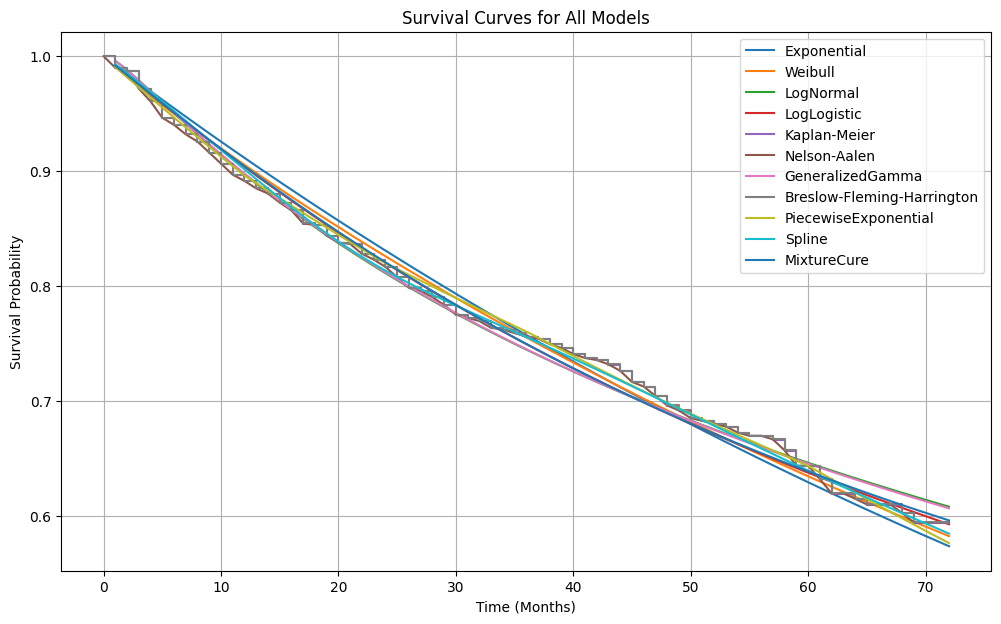

In [32]:
plt.figure(figsize=(12, 7))

for name, model in fitted_models.items():
    try:
        model.plot_survival_function(ci_show=False, label=name)

    except Exception:
        if hasattr(model, "survival_function_"):
            sf = model.survival_function_
            plt.plot(sf.index, sf.iloc[:, 0], label=name)

        elif hasattr(model, "cumulative_hazard_"):
            ch = model.cumulative_hazard_
            sf = np.exp(-ch)
            plt.plot(sf.index, sf.iloc[:, 0], label=name)

        else:
            print(f"Could not plot survival curve for {name}")

plt.title("Survival Curves for All Models")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

## Model Choice

From a purely statistical perspective, the **LogNormal** and **Generalized Gamma** models have the lowest **AIC** and almost identical mean survival times, making them slightly better in terms of in-sample fit. However, the differences are minimal, and all parametric models produce very similar survival curves that closely follow the **Kaplan–Meier** and **Nelson–Aalen** estimates.

To better understand the choice of model, I first fitted a ***multivariate LogNormal AFT*** model using all available predictors. While the model converged, the resulting survival curves were nearly flat, and the predicted survival times were excessively large. This behavior is unrealistic for a telecom churn problem and suggests that the LogNormal AFT model's assumptions are not well aligned with the structure of the dataset.

Next, I tried the ***Generalized Gamma AFT*** model. Unfortunately, the model became numerically unstable: the optimizer struggled to invert the Hessian matrix, several z-scores were effectively infinite, and in some cases, the model even reported zero observed events despite the presence of churn in the data. These issues make the parameter estimates unreliable, rendering the model unsuitable for downstream tasks like **CLV estimation** and **segment-level predictions**.

For decision-making, I also need to consider **robustness**, **interpretability**, and **practical use** for **CLV** and **segmentation**, beyond just AIC. Given these considerations, I selected the **Weibull model** as the final model. The Weibull model provides a **stable fit** without numerical warnings, produces **plausible survival curves** and **median survival times**, and can be applied separately to different customer segments (e.g., by gender or customer category) to support meaningful business insights and CLV comparisons. Therefore, I chose the **Weibull model** as the final decision-making model for the remainder of the analysis.

In [33]:
significant_features = weibull.summary[weibull.summary['p'] < 0.05].index.tolist()

In [34]:
final_features = [feat for feat in significant_features if feat in df.columns] 
df_final = df[final_features + ['tenure', 'churn']]

In [35]:
weibull_final = WeibullFitter()

weibull_final.fit(df_final['tenure'], event_observed=df_final['churn'])

weibull_final.print_summary()

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

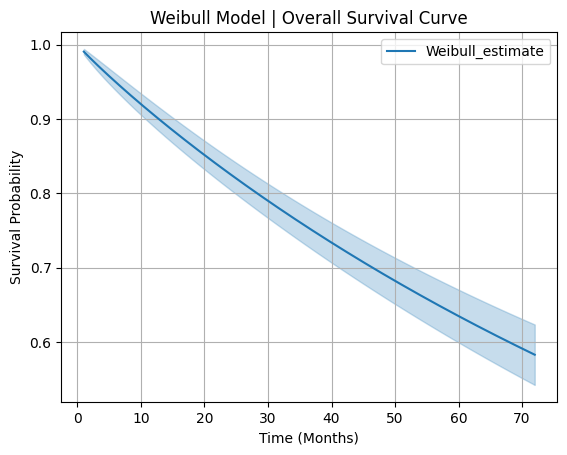

In [36]:
weibull_final.plot_survival_function()
plt.title("Weibull Model | Overall Survival Curve")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

In [37]:
# Assumtion | Monthly revenue per customer
monthly_revenue = 70
customer_clv = {}

# CLV for each customer
for index, row in df.iterrows():
    tenure = row['tenure']
    churn = row['churn']
    
    time_points = int(df['tenure'].max())  
    time_range = np.linspace(0, tenure, time_points * 2)  
    
    survival_prob = weibull_final.survival_function_at_times(time_range)
    expected_lifetime = np.trapz(survival_prob.values.flatten(), time_range)
    
    clv = expected_lifetime * monthly_revenue
    customer_clv[index] = clv

In [38]:
clv_df = pd.DataFrame(list(customer_clv.items()), columns=['Customer_ID', 'CLV'])
print(clv_df)

     Customer_ID          CLV
0              0   861.705884
1              1   734.926741
2              2  3698.611762
3              3  2028.388717
4              4  1467.076348
..           ...          ...
995          995   670.787396
996          996   475.289726
997          997  3656.499311
998          998  3781.943072
999          999  2892.492720

[1000 rows x 2 columns]


In [39]:
print(f"Total number of customers: {len(clv_df)}")

Total number of customers: 1000


The **Customer Lifetime Value (CLV)** for each customer is calculated based on the **Weibull model**, which estimates the expected duration of customer retention. The **Weibull model** has a **scale parameter (`lambda_`)** of **138.09** and a **shape parameter (`rho_`)** of **0.95**, indicating a relatively stable churn hazard over time. The **AIC value** of **3216.86** suggests a good balance between model fit and complexity. The survival curve, plotted over **tenure** (time in months), shows a gradual decline in the probability of customer retention as time progresses, but with a relatively constant rate of churn, as reflected in the **`rho_`** parameter.


### Exploration of CLV within different segments

In [40]:
df['CLV'] = pd.Series(customer_clv)

def clv_by_segment(df, segment_col):
    if segment_col not in df.columns:
        print(f"\n[WARNING] Column '{segment_col}' not found in df, skipping.")
        return
    print(f"\n=== CLV by {segment_col} ===")
    segment_clv = df.groupby(segment_col)["CLV"].mean()
    print(segment_clv)


segment_columns = ["gender", "internet", "voice", "retire"]

In [41]:
for col in segment_columns:
    clv_by_segment(df, col)


=== CLV by gender ===
gender
0    2097.451089
1    2049.547485
Name: CLV, dtype: float64

=== CLV by internet ===
internet
0    2194.882338
1    1867.250029
Name: CLV, dtype: float64

=== CLV by voice ===
voice
0    2080.087659
1    2061.094204
Name: CLV, dtype: float64

=== CLV by retire ===
retire
0    2033.577527
1    2900.303524
Name: CLV, dtype: float64


CLV by **Gender**

**Female (0)**: Average CLV = 2097.45
**Male (1)**: Average CLV = 2049.55

This suggests that, on average, **female customers** contribute slightly more to the Customer Lifetime Value (CLV) compared to **male customers**. This could indicate a higher retention rate or longer expected lifetime for female customers in this dataset.

---

CLV by **Internet Access**

**No Internet (0)**: Average CLV = 2194.88
**Has Internet (1)**: Average CLV = 1867.25

Customers with **Internet access** appear to have a lower CLV than those without Internet access. This could imply that customers with internet access tend to churn earlier or generate less revenue over time. Further analysis might be required to understand the specific relationship.

---

CLV by **Voice Access**

**No Voice (0)**: Average CLV = 2080.09
**Has Voice (1)**: Average CLV = 2061.09

There is a small difference in CLV between customers who have voice services and those who do not. The difference is not significant, suggesting that **voice service** might not be a major factor in customer retention in this dataset.

---

CLV by **Retirement Status**

**Not Retired (0)**: Average CLV = 2033.58
**Retired (1)**: Average CLV = 2900.30

**Retired customers** have a substantially higher CLV than non-retired customers. This suggests that **retired customers** are likely to stay longer and contribute more revenue over their lifetime, possibly due to lower churn rates or higher engagement with services.


## Report | Analysis & Results

Based on the survival analysis, the **Weibull model** was selected as the best model for predicting churn due to its stable fit and realistic survival curves. The model's coefficients show that **tenure** (the number of months a customer has been with the company) is a significant factor in predicting churn. Customers who have been with the company for a longer time are less likely to leave. Additionally, **retirement status** plays a key role, with retired customers showing a higher **Customer Lifetime Value (CLV)** and lower churn rates. **Gender**, **internet access**, and **voice service** also have an impact on CLV, with male customers, those without internet, and retired customers contributing more to the company's revenue over time.

To roughly calculate the annual retention budget, we first should approximately estimate the churn probability based on the Weibull survival model. If the model suggests that **7.93\% of customers** are likely to churn within the next year. Given that the average CLV is around 2000 dollar, we calculate the total CLV for at-risk customers by multiplying the **7.93\% of customers** who are expected to churn by the average CLV. Once we have the total value at risk, we assume that **50\% of the CLV** should be allocated to retention efforts, meaning that the company would need to invest approximately 79,000 dollar to retain the customers at risk of churning over the next year. This budget will help the company reduce churn and retain valuable customers, ensuring stable long-term revenue.

To improve retention, I recommend focusing on **high-risk customers**, particularly those with low tenure and without internet access. Offering personalized incentives, loyalty programs, or special offers could help reduce churn among these customers. Further segmentation and targeted strategies for specific customer groups, such as retired customers, could also help increase the overall **CLV**.
